PART 0: The Coin Toss (Bernoulli Distribution)
True bias of the coin: p = 0.65
Estimated bias (MLE) after 100 tosses: p_hat = 0.6800


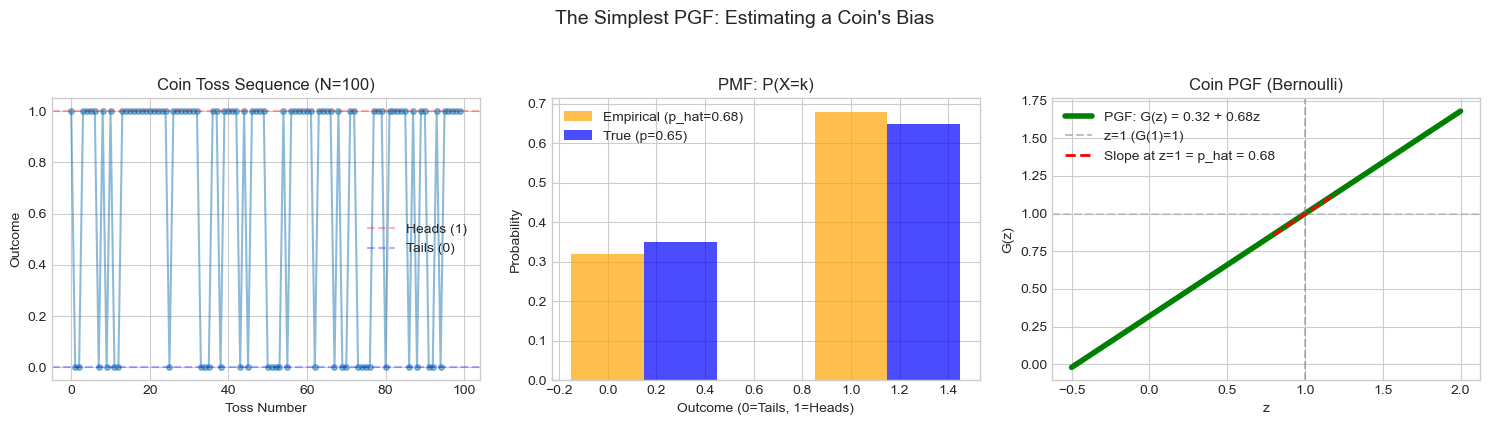


PART 1: Classification (The 'Conditional Coin' - Logistic Regression)


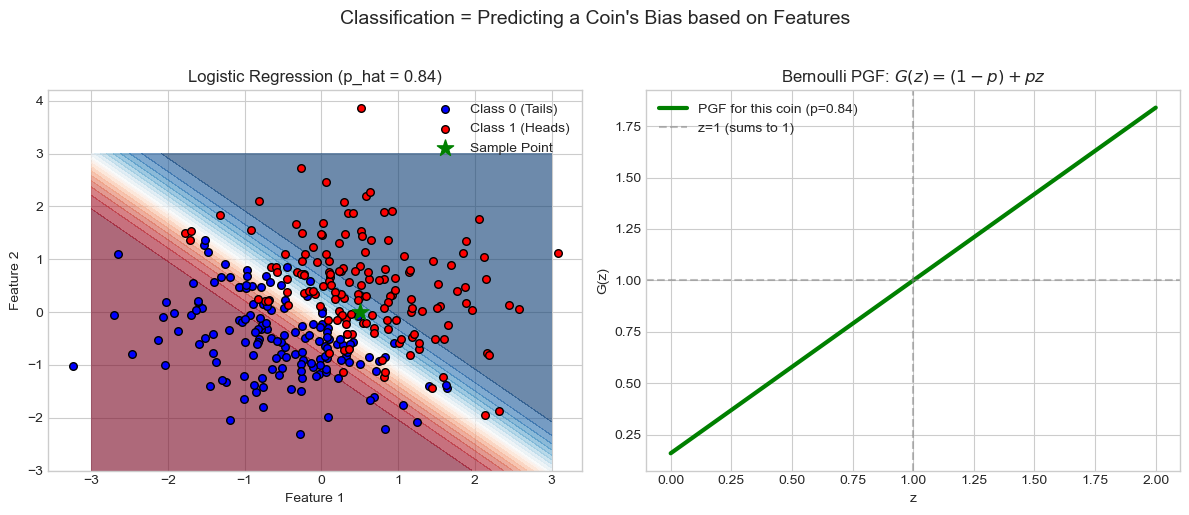


PART 2: Count Regression (Poisson - Predicting Rates)


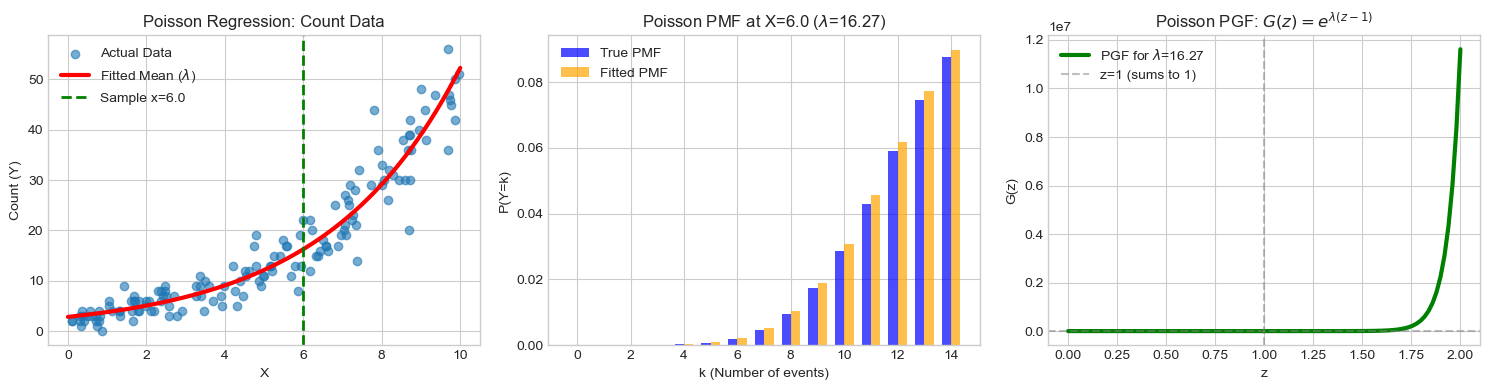


PART 3: Continuous Regression (Gaussian - MGF)


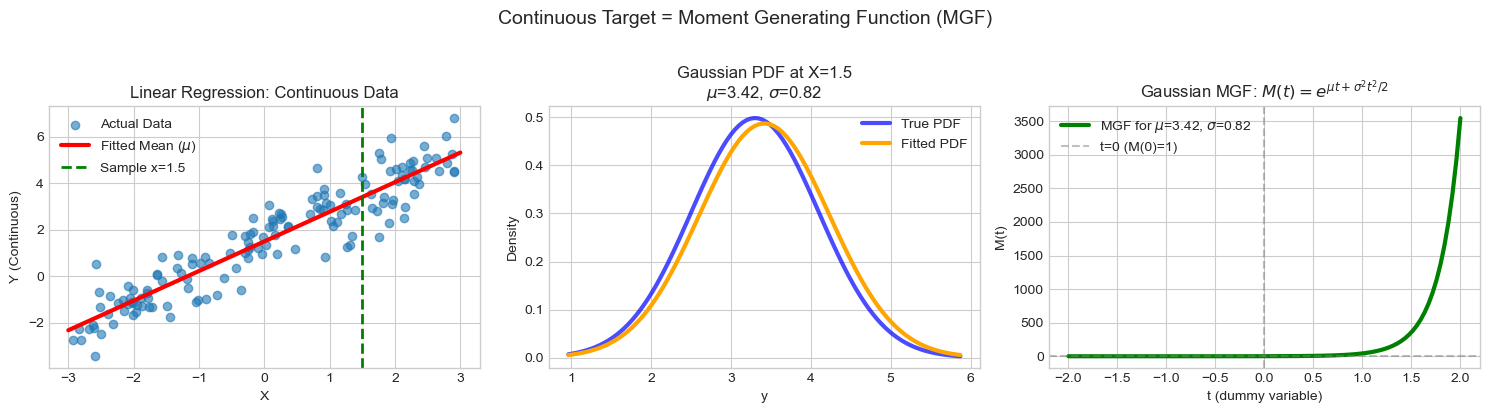


Summary of the Progression:
1. Coin Toss -> Simple Bernoulli PGF (p is constant).
2. Logistic Regression -> Conditional Bernoulli PGF (p depends on X).
3. Poisson Regression -> PGF for counts (e^{λ(z-1)}).
4. Linear Regression -> MGF for continuous targets (e^{μt + σ²t²/2}).
In all cases, ML learns the parameters of the generating function!


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.linear_model import LogisticRegression, LinearRegression
from scipy.stats import poisson, norm, bernoulli

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

# ================================================================
# PART 0: THE COIN EXAMPLE (Simplest PGF)
# ================================================================
print("="*60)
print("PART 0: The Coin Toss (Bernoulli Distribution)")
print("="*60)

# Simulate tossing a biased coin N times
true_p = 0.65          # The true, unknown bias of the coin
N_tosses = 100
coin_flips = np.random.binomial(1, true_p, N_tosses)  # 1 = Heads, 0 = Tails

# MLE for the coin's bias: just count the heads!
p_mle = np.mean(coin_flips)
print(f"True bias of the coin: p = {true_p}")
print(f"Estimated bias (MLE) after {N_tosses} tosses: p_hat = {p_mle:.4f}")

# Bernoulli PGF: G(z) = E[z^X] = (1-p) + p*z
z_vals = np.linspace(-0.5, 2.0, 200)
pgf_coin = (1 - p_mle) + p_mle * z_vals

# Let's also look at the derivatives at z=1 to get moments
# G'(1) = p (mean), G''(1) = 0? Actually Var(X) = p(1-p) = G''(1) + G'(1) - G'(1)^2
mean_derived = p_mle  # First derivative at z=1
var_derived = p_mle * (1 - p_mle)  # Variance

# Plotting the Coin Example
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Left: Raw Data (Sequence of Tosses)
axes[0].plot(coin_flips, 'o-', alpha=0.5, markersize=4)
axes[0].axhline(y=1, color='red', linestyle='--', alpha=0.3, label='Heads (1)')
axes[0].axhline(y=0, color='blue', linestyle='--', alpha=0.3, label='Tails (0)')
axes[0].set_title(f'Coin Toss Sequence (N={N_tosses})')
axes[0].set_xlabel('Toss Number'); axes[0].set_ylabel('Outcome')
axes[0].legend()

# Middle: Empirical PMF vs True PMF
k_vals = [0, 1]
empirical_pmf = [np.mean(coin_flips == 0), np.mean(coin_flips == 1)]
true_pmf = [1 - true_p, true_p]
axes[1].bar(k_vals, empirical_pmf, width=0.3, label=f'Empirical (p_hat={p_mle:.2f})', alpha=0.7, color='orange')
axes[1].bar([k+0.3 for k in k_vals], true_pmf, width=0.3, label=f'True (p={true_p})', alpha=0.7, color='blue')
axes[1].set_title('PMF: P(X=k)')
axes[1].set_xlabel('Outcome (0=Tails, 1=Heads)')
axes[1].set_ylabel('Probability')
axes[1].legend()

# Right: The Probability Generating Function
axes[2].plot(z_vals, pgf_coin, 'g-', lw=4, label=f'PGF: G(z) = {1-p_mle:.2f} + {p_mle:.2f}z')
axes[2].set_title('Coin PGF (Bernoulli)')
axes[2].set_xlabel('z')
axes[2].set_ylabel('G(z)')
axes[2].axvline(x=1, color='gray', linestyle='--', alpha=0.5, label='z=1 (G(1)=1)')
axes[2].axhline(y=1, color='gray', linestyle='--', alpha=0.3)
# Mark the derivative at z=1 (slope = p)
slope = p_mle
axes[2].plot([0.8, 1.2], [pgf_coin[np.abs(z_vals-0.8).argmin()], pgf_coin[np.abs(z_vals-1.2).argmin()]], 
             'r--', lw=2, label=f"Slope at z=1 = p_hat = {p_mle:.2f}")
axes[2].legend()
plt.suptitle("The Simplest PGF: Estimating a Coin's Bias", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

# ================================================================
# PART 1: CLASSIFICATION (Logistic Regression = "Conditional Coin")
# ================================================================
print("\n" + "="*60)
print("PART 1: Classification (The 'Conditional Coin' - Logistic Regression)")
print("="*60)

# Generate 2D data where the "coin's bias" depends on the input X
X_clf = np.random.randn(300, 2)
y_clf = (X_clf[:, 0] + X_clf[:, 1] + 0.5 * np.random.randn(300) > 0).astype(int)

# Fit Logistic Regression (learns p(X) = P(Y=1 | X))
model_clf = LogisticRegression()
model_clf.fit(X_clf, y_clf)

# Create mesh for decision boundary
xx, yy = np.meshgrid(np.linspace(-3, 3, 100), np.linspace(-3, 3, 100))
Z = model_clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

# Pick a specific test point to show its PGF
test_point = np.array([[0.5, 0.0]])
p_hat = model_clf.predict_proba(test_point)[0, 1]  # Probability of class 1 (the coin's bias here)

# Bernoulli PGF for this specific point: G(z) = 1 - p + p*z
z_vals = np.linspace(0, 2, 100)
pgf_bern = (1 - p_hat) + p_hat * z_vals

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Decision Boundary
axes[0].contourf(xx, yy, Z, levels=np.linspace(0, 1, 20), cmap='RdBu', alpha=0.6)
axes[0].scatter(X_clf[y_clf==0, 0], X_clf[y_clf==0, 1], c='blue', s=30, edgecolor='k', label='Class 0 (Tails)')
axes[0].scatter(X_clf[y_clf==1, 0], X_clf[y_clf==1, 1], c='red', s=30, edgecolor='k', label='Class 1 (Heads)')
axes[0].scatter(test_point[0,0], test_point[0,1], c='green', s=150, marker='*', label='Sample Point')
axes[0].set_title(f'Logistic Regression (p_hat = {p_hat:.2f})')
axes[0].set_xlabel('Feature 1'); axes[0].set_ylabel('Feature 2')
axes[0].legend()

# Right: The Probability Generating Function for that point
axes[1].plot(z_vals, pgf_bern, 'g-', lw=3, label=f'PGF for this coin (p={p_hat:.2f})')
axes[1].set_title('Bernoulli PGF: $G(z) = (1-p) + pz$')
axes[1].set_xlabel('z')
axes[1].set_ylabel('G(z)')
axes[1].axvline(x=1, color='gray', linestyle='--', alpha=0.5, label='z=1 (sums to 1)')
axes[1].axhline(y=1, color='gray', linestyle='--', alpha=0.5)
axes[1].legend()
plt.suptitle("Classification = Predicting a Coin's Bias based on Features", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ================================================================
# PART 2: COUNT REGRESSION (Poisson Distribution)
# ================================================================
print("\n" + "="*60)
print("PART 2: Count Regression (Poisson - Predicting Rates)")
print("="*60)

# Simulate count data
X_poi = np.random.uniform(0, 10, 150).reshape(-1, 1)
true_lambda = np.exp(1.0 + 0.3 * X_poi).flatten()
y_poi = np.random.poisson(true_lambda)

# Poisson Regression via Maximum Likelihood
def neg_log_likelihood_poisson(theta, X, y):
    intercept, slope = theta
    lam = np.exp(intercept + slope * X.flatten())
    return -np.sum(y * np.log(lam) - lam)

res = minimize(neg_log_likelihood_poisson, [0, 0], args=(X_poi, y_poi), method='L-BFGS-B')
intercept_poi, slope_poi = res.x

# Predict for a specific X value
x_sample = 6.0
lambda_hat = np.exp(intercept_poi + slope_poi * x_sample)

# Plot PGF for Poisson: G(z) = exp(lambda(z-1))
z_vals = np.linspace(0, 2, 100)
pgf_poi = np.exp(lambda_hat * (z_vals - 1))

# Compare theoretical true PMF vs fitted PMF for the sample point
k_vals = np.arange(0, 15)
pmf_true = poisson.pmf(k_vals, true_lambda[np.argmin(np.abs(X_poi.flatten() - x_sample))])
pmf_fitted = poisson.pmf(k_vals, lambda_hat)

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Left: Data & Fitted Curve
axes[0].scatter(X_poi, y_poi, alpha=0.6, label='Actual Data')
x_range = np.linspace(0, 10, 100)
fitted_mean = np.exp(intercept_poi + slope_poi * x_range)
axes[0].plot(x_range, fitted_mean, 'r-', lw=3, label='Fitted Mean ($\lambda$)')
axes[0].axvline(x=x_sample, color='green', linestyle='--', lw=2, label=f'Sample x={x_sample}')
axes[0].set_title('Poisson Regression: Count Data')
axes[0].set_xlabel('X'); axes[0].set_ylabel('Count (Y)')
axes[0].legend()

# Middle: PMF comparison for the sample point
width = 0.35
axes[1].bar(k_vals - width/2, pmf_true, width=width, label='True PMF', alpha=0.7, color='blue')
axes[1].bar(k_vals + width/2, pmf_fitted, width=width, label='Fitted PMF', alpha=0.7, color='orange')
axes[1].set_title(f'Poisson PMF at X={x_sample} ($\lambda$={lambda_hat:.2f})')
axes[1].set_xlabel('k (Number of events)'); axes[1].set_ylabel('P(Y=k)')
axes[1].legend()

# Right: The Probability Generating Function
axes[2].plot(z_vals, pgf_poi, 'g-', lw=3, label=f'PGF for $\lambda$={lambda_hat:.2f}')
axes[2].set_title('Poisson PGF: $G(z) = e^{\lambda(z-1)}$')
axes[2].set_xlabel('z')
axes[2].set_ylabel('G(z)')
axes[2].axvline(x=1, color='gray', linestyle='--', alpha=0.5, label='z=1 (sums to 1)')
axes[2].axhline(y=1, color='gray', linestyle='--', alpha=0.5)
axes[2].legend()
plt.tight_layout()
plt.show()

# ================================================================
# PART 3: CONTINUOUS REGRESSION (Gaussian - MGF)
# ================================================================
print("\n" + "="*60)
print("PART 3: Continuous Regression (Gaussian - MGF)")
print("="*60)

# Simulate continuous data
X_gauss = np.random.uniform(-3, 3, 150).reshape(-1, 1)
true_mu = 1.5 + 1.2 * X_gauss.flatten()
y_gauss = true_mu + 0.8 * np.random.randn(150)

# Fit Linear Regression
model_lin = LinearRegression()
model_lin.fit(X_gauss, y_gauss)

# Predict for a specific X value
x_sample_gauss = 1.5
mu_hat = model_lin.predict([[x_sample_gauss]])[0]
sigma_hat = np.std(y_gauss - model_lin.predict(X_gauss))  # Residual std

# Gaussian MGF: M(t) = exp(mu*t + (sigma^2 * t^2)/2)
t_vals = np.linspace(-2, 2, 100)
mgf_gauss = np.exp(mu_hat * t_vals + 0.5 * sigma_hat**2 * t_vals**2)

# True conditional distribution for the sample point
true_mu_sample = 1.5 + 1.2 * x_sample_gauss

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Left: Data & Fitted Line
axes[0].scatter(X_gauss, y_gauss, alpha=0.6, label='Actual Data')
x_range = np.linspace(-3, 3, 100)
axes[0].plot(x_range, model_lin.predict(x_range.reshape(-1,1)), 'r-', lw=3, label='Fitted Mean ($\mu$)')
axes[0].axvline(x=x_sample_gauss, color='green', linestyle='--', lw=2, label=f'Sample x={x_sample_gauss}')
axes[0].set_title('Linear Regression: Continuous Data')
axes[0].set_xlabel('X'); axes[0].set_ylabel('Y (Continuous)')
axes[0].legend()

# Middle: Gaussian PDF comparison for the sample point
x_pdf = np.linspace(mu_hat - 3*sigma_hat, mu_hat + 3*sigma_hat, 100)
pdf_true = norm.pdf(x_pdf, true_mu_sample, 0.8)
pdf_fitted = norm.pdf(x_pdf, mu_hat, sigma_hat)

axes[1].plot(x_pdf, pdf_true, 'b-', lw=3, label='True PDF', alpha=0.7)
axes[1].plot(x_pdf, pdf_fitted, 'orange', lw=3, label='Fitted PDF')
axes[1].set_title(f'Gaussian PDF at X={x_sample_gauss}\n$\mu$={mu_hat:.2f}, $\sigma$={sigma_hat:.2f}')
axes[1].set_xlabel('y'); axes[1].set_ylabel('Density')
axes[1].legend()

# Right: The Moment Generating Function
axes[2].plot(t_vals, mgf_gauss, 'g-', lw=3, label=f'MGF for $\mu$={mu_hat:.2f}, $\sigma$={sigma_hat:.2f}')
axes[2].set_title('Gaussian MGF: $M(t) = e^{\mu t + \sigma^2 t^2/2}$')
axes[2].set_xlabel('t (dummy variable)')
axes[2].set_ylabel('M(t)')
axes[2].axvline(x=0, color='gray', linestyle='--', alpha=0.5, label='t=0 (M(0)=1)')
axes[2].axhline(y=1, color='gray', linestyle='--', alpha=0.5)
axes[2].legend()
plt.suptitle("Continuous Target = Moment Generating Function (MGF)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("Summary of the Progression:")
print("1. Coin Toss -> Simple Bernoulli PGF (p is constant).")
print("2. Logistic Regression -> Conditional Bernoulli PGF (p depends on X).")
print("3. Poisson Regression -> PGF for counts (e^{λ(z-1)}).")
print("4. Linear Regression -> MGF for continuous targets (e^{μt + σ²t²/2}).")
print("In all cases, ML learns the parameters of the generating function!")
print("="*60)

GAUSSIAN COIN: Modeling a coin's features with Gaussian MGFs
Estimated Prior P(Heads) = 0.657 (True: 0.65)
Estimated Mean (Tails): [-1.03131268 -0.52212803]
Estimated Mean (Heads): [2.00698745 1.48574015]

For a coin with features [1.  0.5]:
  P(Heads | X) = 0.9151  (This is the coin's conditional bias)


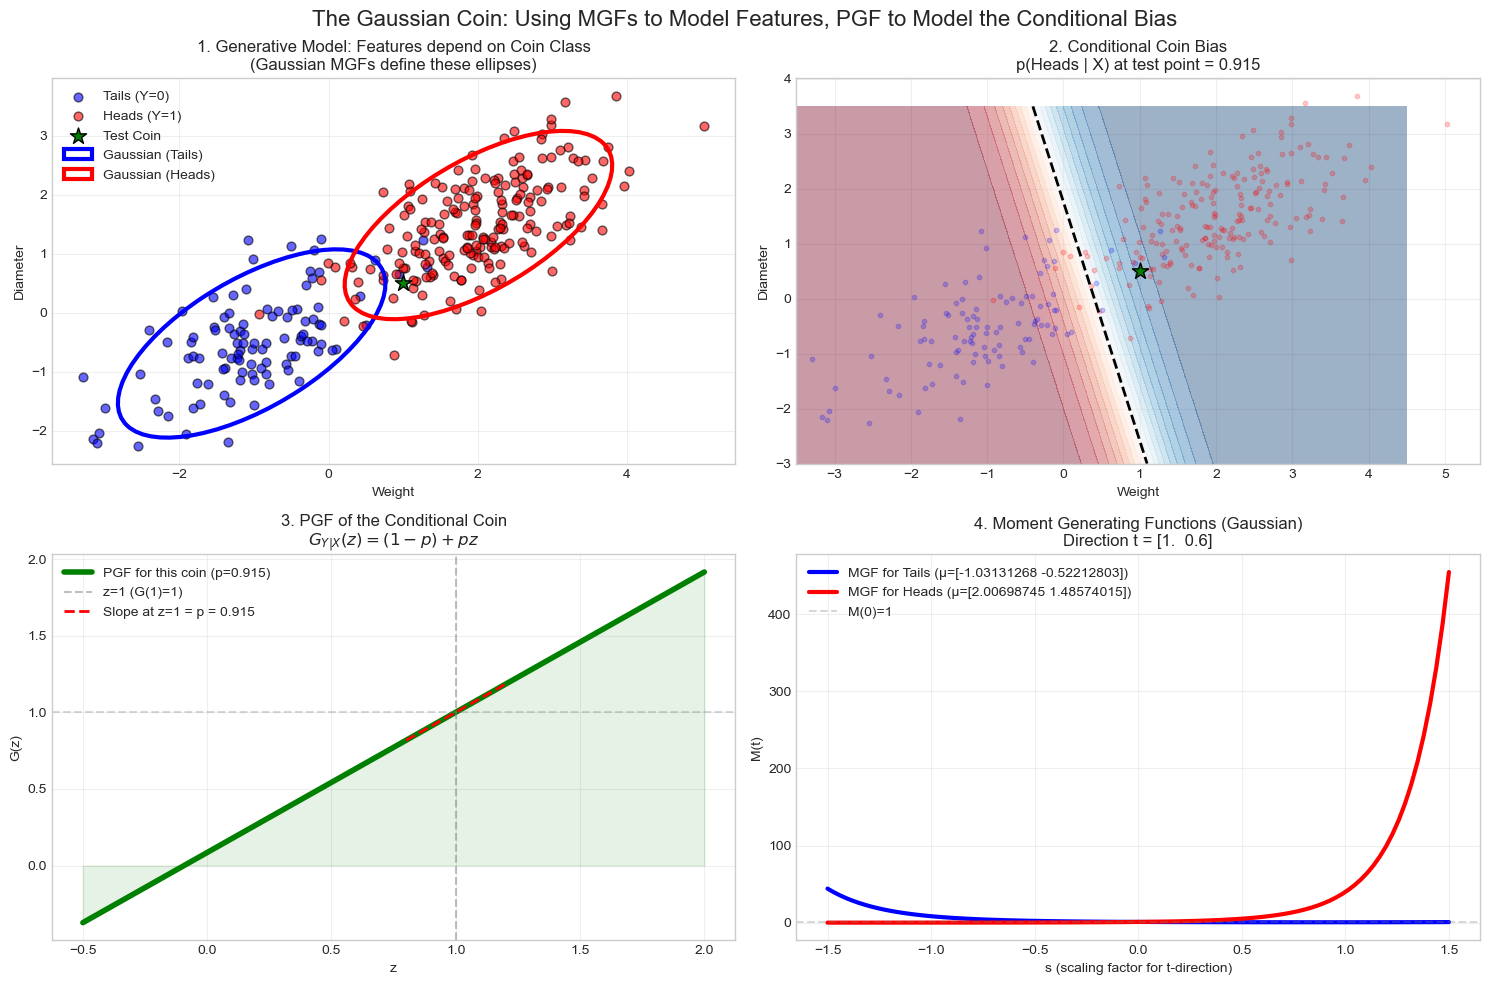


KEY TAKEAWAYS (The Gaussian Coin):
1. The Features (Weight/Diameter) are modeled by Gaussians.
   - MGFs of these Gaussians determine how features spread per class.
2. The Coin's 'Bias' is no longer constant; it depends on the features.
   - p = P(Heads | X) is given by Bayes' rule (sigmoid shape).
3. The PGF G(z) = (1-p) + p z still describes the conditional coin.
   - The slope at z=1 is the conditional bias p.
4. Classification = Inferring the coin's bias from its Gaussian features.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, bernoulli
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

# ================================================================
# GAUSSIAN DISCRIMINANT ANALYSIS (GDA) FOR A COIN
# We observe continuous features (e.g., weight, diameter) of a coin.
# The class (Heads=1 / Tails=0) determines the Gaussian distribution.
# ================================================================

def plot_gaussian_ellipse(mean, cov, ax, color, label, n_std=2.0):
    """Plot an ellipse representing the covariance matrix."""
    eigvals, eigvecs = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
    width, height = 2 * n_std * np.sqrt(eigvals)
    ell = Ellipse(xy=mean, width=width, height=height, angle=angle, 
                  edgecolor=color, facecolor='none', lw=3, label=label)
    ax.add_patch(ell)
    return ell

print("="*60)
print("GAUSSIAN COIN: Modeling a coin's features with Gaussian MGFs")
print("="*60)

# --- 1. Generate synthetic "coin" data ---
# Prior probability of Heads
phi_true = 0.65  

# Feature distributions for Tails (Y=0) and Heads (Y=1)
mu_0 = np.array([-1.0, -0.5])
mu_1 = np.array([2.0, 1.5])
# Shared covariance matrix (tied GDA)
Sigma = np.array([[0.8, 0.4], 
                  [0.4, 0.6]])

# Number of samples
N = 300
y_true = np.random.binomial(1, phi_true, N)

# Generate features based on the class
X_gda = np.zeros((N, 2))
for i in range(N):
    if y_true[i] == 0:
        X_gda[i] = np.random.multivariate_normal(mu_0, Sigma)
    else:
        X_gda[i] = np.random.multivariate_normal(mu_1, Sigma)

# --- 2. Fit the GDA model via MLE ---
# Prior
phi_hat = np.mean(y_true)

# Class means
mu_0_hat = np.mean(X_gda[y_true == 0], axis=0)
mu_1_hat = np.mean(X_gda[y_true == 1], axis=0)

# Shared covariance matrix (weighted average)
cov_0 = np.cov(X_gda[y_true == 0], rowvar=False)
cov_1 = np.cov(X_gda[y_true == 1], rowvar=False)
Sigma_hat = ((len(y_true[y_true==0]) - 1) * cov_0 + (len(y_true[y_true==1]) - 1) * cov_1) / (N - 2)

print(f"Estimated Prior P(Heads) = {phi_hat:.3f} (True: {phi_true})")
print(f"Estimated Mean (Tails): {mu_0_hat}")
print(f"Estimated Mean (Heads): {mu_1_hat}")

# --- 3. Compute the Conditional Coin Bias for a specific test point ---
# Pick a specific coin with measured features
test_point = np.array([1.0, 0.5])

# Gaussian likelihoods for the test point
likelihood_0 = multivariate_normal.pdf(test_point, mean=mu_0_hat, cov=Sigma_hat)
likelihood_1 = multivariate_normal.pdf(test_point, mean=mu_1_hat, cov=Sigma_hat)

# Bayes rule: Posterior probability (the bias of THIS coin)
p_hat = (phi_hat * likelihood_1) / (phi_hat * likelihood_1 + (1 - phi_hat) * likelihood_0)
print(f"\nFor a coin with features {test_point}:")
print(f"  P(Heads | X) = {p_hat:.4f}  (This is the coin's conditional bias)")

# --- 4. The PGF of the conditional coin ---
z_vals = np.linspace(-0.5, 2.0, 200)
pgf_coin = (1 - p_hat) + p_hat * z_vals

# --- 5. The MGFs of the Gaussian features (for each class) ---
# MGF of a Gaussian: M(t) = exp(mu^T t + 0.5 * t^T Sigma t)
def gaussian_mgf(t, mu, cov):
    return np.exp(np.dot(mu, t) + 0.5 * np.dot(t, np.dot(cov, t)))

# For visualization, we evaluate MGF along the direction t = [s, 0.5*s] just to show a slice
s_vals = np.linspace(-1.5, 1.5, 100)
t_dir = np.array([1.0, 0.6])  # A direction in the t-space
t_vectors = np.outer(s_vals, t_dir)  # Shape (100, 2)

mgf_0 = [gaussian_mgf(t, mu_0_hat, Sigma_hat) for t in t_vectors]
mgf_1 = [gaussian_mgf(t, mu_1_hat, Sigma_hat) for t in t_vectors]

# ================================================================
# PLOTTING
# ================================================================
fig = plt.figure(figsize=(15, 10))

# --- Subplot 1: Data and Gaussian Contours (The Generative Model) ---
ax1 = fig.add_subplot(2, 2, 1)
ax1.scatter(X_gda[y_true==0, 0], X_gda[y_true==0, 1], 
            c='blue', s=40, edgecolor='k', alpha=0.6, label='Tails (Y=0)')
ax1.scatter(X_gda[y_true==1, 0], X_gda[y_true==1, 1], 
            c='red', s=40, edgecolor='k', alpha=0.6, label='Heads (Y=1)')
ax1.scatter(test_point[0], test_point[1], c='green', s=150, 
            marker='*', edgecolor='black', label='Test Coin', zorder=10)

# Plot Gaussian ellipses (2 standard deviations)
plot_gaussian_ellipse(mu_0_hat, Sigma_hat, ax1, color='blue', label='Gaussian (Tails)')
plot_gaussian_ellipse(mu_1_hat, Sigma_hat, ax1, color='red', label='Gaussian (Heads)')

ax1.set_title('1. Generative Model: Features depend on Coin Class\n(Gaussian MGFs define these ellipses)')
ax1.set_xlabel('Weight'); ax1.set_ylabel('Diameter')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Subplot 2: The Conditional Bias (Sigmoid Decision Boundary) ---
ax2 = fig.add_subplot(2, 2, 2)
# Create a grid to compute the posterior p(x) over the feature space
xx, yy = np.meshgrid(np.linspace(-3.5, 4.5, 100), np.linspace(-3, 3.5, 100))
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Compute likelihoods for the grid
likelihood_0_grid = multivariate_normal.pdf(grid_points, mean=mu_0_hat, cov=Sigma_hat)
likelihood_1_grid = multivariate_normal.pdf(grid_points, mean=mu_1_hat, cov=Sigma_hat)
p_grid = (phi_hat * likelihood_1_grid) / (phi_hat * likelihood_1_grid + (1 - phi_hat) * likelihood_0_grid)
p_grid = p_grid.reshape(xx.shape)

# Plot the decision boundary (where p=0.5)
ax2.contourf(xx, yy, p_grid, levels=np.linspace(0, 1, 20), cmap='RdBu', alpha=0.4)
ax2.contour(xx, yy, p_grid, levels=[0.5], colors='black', linewidths=2, linestyles='--')

# ----- FIX: Scatter the original data correctly (color by true class) -----
ax2.scatter(X_gda[y_true==0, 0], X_gda[y_true==0, 1], alpha=0.2, s=10, color='blue')
ax2.scatter(X_gda[y_true==1, 0], X_gda[y_true==1, 1], alpha=0.2, s=10, color='red')

# Mark the test point
ax2.scatter(test_point[0], test_point[1], c='green', s=150, marker='*', edgecolor='black', label='Test Coin', zorder=10)

ax2.set_title(f'2. Conditional Coin Bias\np(Heads | X) at test point = {p_hat:.3f}')
ax2.set_xlabel('Weight'); ax2.set_ylabel('Diameter')
ax2.grid(True, alpha=0.3)

# --- Subplot 3: The Bernoulli PGF for the Test Coin ---
ax3 = fig.add_subplot(2, 2, 3)
ax3.plot(z_vals, pgf_coin, 'g-', lw=4, label=f'PGF for this coin (p={p_hat:.3f})')
ax3.fill_between(z_vals, 0, pgf_coin, alpha=0.1, color='green')
ax3.set_title(f'3. PGF of the Conditional Coin\n$G_{{Y|X}}(z) = (1-p) + pz$')
ax3.set_xlabel('z')
ax3.set_ylabel('G(z)')
ax3.axvline(x=1, color='gray', linestyle='--', alpha=0.5, label='z=1 (G(1)=1)')
ax3.axhline(y=1, color='gray', linestyle='--', alpha=0.3)
# Show the slope (mean) at z=1
ax3.plot([0.8, 1.2], [(1 - p_hat) + p_hat*0.8, (1 - p_hat) + p_hat*1.2], 
         'r--', lw=2, label=f"Slope at z=1 = p = {p_hat:.3f}")
ax3.legend()
ax3.grid(True, alpha=0.3)

# --- Subplot 4: The Gaussian MGFs (for the two classes) ---
ax4 = fig.add_subplot(2, 2, 4)
ax4.plot(s_vals, mgf_0, 'b-', lw=3, label=f'MGF for Tails (μ={mu_0_hat})')
ax4.plot(s_vals, mgf_1, 'r-', lw=3, label=f'MGF for Heads (μ={mu_1_hat})')
ax4.set_title(f'4. Moment Generating Functions (Gaussian)\nDirection t = {t_dir}')
ax4.set_xlabel('s (scaling factor for t-direction)')
ax4.set_ylabel('M(t)')
ax4.axhline(y=1, color='gray', linestyle='--', alpha=0.3, label='M(0)=1')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle('The Gaussian Coin: Using MGFs to Model Features, PGF to Model the Conditional Bias', 
             fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

# ================================================================
# SUMMARY FOR STUDENTS
# ================================================================
print("\n" + "="*60)
print("KEY TAKEAWAYS (The Gaussian Coin):")
print("="*60)
print("1. The Features (Weight/Diameter) are modeled by Gaussians.")
print("   - MGFs of these Gaussians determine how features spread per class.")
print("2. The Coin's 'Bias' is no longer constant; it depends on the features.")
print("   - p = P(Heads | X) is given by Bayes' rule (sigmoid shape).")
print("3. The PGF G(z) = (1-p) + p z still describes the conditional coin.")
print("   - The slope at z=1 is the conditional bias p.")
print("4. Classification = Inferring the coin's bias from its Gaussian features.")
print("="*60)